#### Biggest strides in decreasing CO2 output

**Which countries are making the biggest strides in decreasing CO2 output?**

You'll need to find the relative CO2 output for each country to be able to calculate this. But countries can have growing and shrinking populations too, so it's probably a good idea to take this into account as well.

In [178]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import YearLocator, DateFormatter

In [179]:
# Import the original CO Emissions per Capita data
# df_original_data = pd.read_csv('https://raw.githubusercontent.com/majavanput/co2-emissions/main/data/co-emissions-per-capita.csv')
df_original_data = pd.read_csv('../data/co-emissions-per-capita.csv')

In [180]:
# Print information about the DataFrame
df_original_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 26509 entries, 0 to 26508
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Entity                    26509 non-null  str    
 1   Code                      25363 non-null  str    
 2   Year                      26509 non-null  int64  
 3   CO₂ emissions per capita  26509 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 828.5 KB


In [181]:
# Overview of missing values per column
for name, values in df_original_data.items():
  print(f'Missing values in column {name}: ', df_original_data[name].isnull().sum())

# Total number of missing values in dataset
total_nan = df_original_data.isnull().sum().sum()
print(f"Total number of NaN values in the DataFrame: {total_nan}")

Missing values in column Entity:  0
Missing values in column Code:  1146
Missing values in column Year:  0
Missing values in column CO₂ emissions per capita:  0
Total number of NaN values in the DataFrame: 1146


In [182]:
df_co2_emissions = df_original_data.copy()

# Drop unnecessary columns
df_co2_emissions.drop(columns=['Code'], inplace=True)

In [183]:
df_co2_emissions.head()

,Entity,Year,CO₂ emissions per capita
0,Afghanistan,1949,0.001992
1,Afghanistan,1950,0.010837
2,Afghanistan,1951,0.011625
3,Afghanistan,1952,0.011468
4,Afghanistan,1953,0.013123


In [184]:
df_co2_filtered = df_co2_emissions.copy()

# Only keep specified years for relative change calculation
df_co2_filtered = df_co2_filtered[df_co2_filtered["Year"].isin([1990, 2000, 2010, 2020])]

In [185]:
df_co2_relative_change = df_co2_filtered.copy()

# Pivot the DataFrame to have the years as columns
df_co2_relative_change = df_co2_relative_change.pivot(
  index=["Entity"],
  columns="Year",
  values="CO₂ emissions per capita"
)

df_co2_relative_change.columns.name = None
df_co2_relative_change.reset_index(inplace=True)
df_co2_relative_change = df_co2_relative_change[['Entity', 1990, 2020]]

# Calculate relative change for 1990-2020
df_co2_relative_change["relative_change_1990_2020"] = (df_co2_relative_change[2020] - df_co2_relative_change[1990]) / df_co2_relative_change[1990]

df_co2_relative_change.head()

,Entity,1990,2020,relative_change_1990_2020
0,Afghanistan,0.168054,0.284590,0.693438
1,Africa,1.020606,0.993473,-0.026585
2,Albania,1.684155,1.693982,0.005835
3,Algeria,2.990726,3.885795,0.299281
4,Andorra,7.660027,4.876055,-0.363442


In [186]:
df_co2_top_10 = df_co2_relative_change.sort_values(by="relative_change_1990_2020", ascending=True).head(10)
df_co2_top_10

,Entity,1990,2020,relative_change_1990_2020
136,Moldova,8.201354,1.665985,-0.796865
112,Kyrgyzstan,4.306276,1.252748,-0.709088
66,Estonia,23.502500,6.917664,-0.705663
216,Ukraine,13.572912,4.635197,-0.658496
52,Curacao,30.812616,10.851662,-0.647818
230,Zimbabwe,1.532660,0.546847,-0.643204
144,Nauru,12.916122,4.711530,-0.635221
55,Democratic Republic of Congo,0.115826,0.044846,-0.612814
123,Luxembourg,30.937780,12.795942,-0.586398
204,Tajikistan,2.279526,0.966562,-0.575981


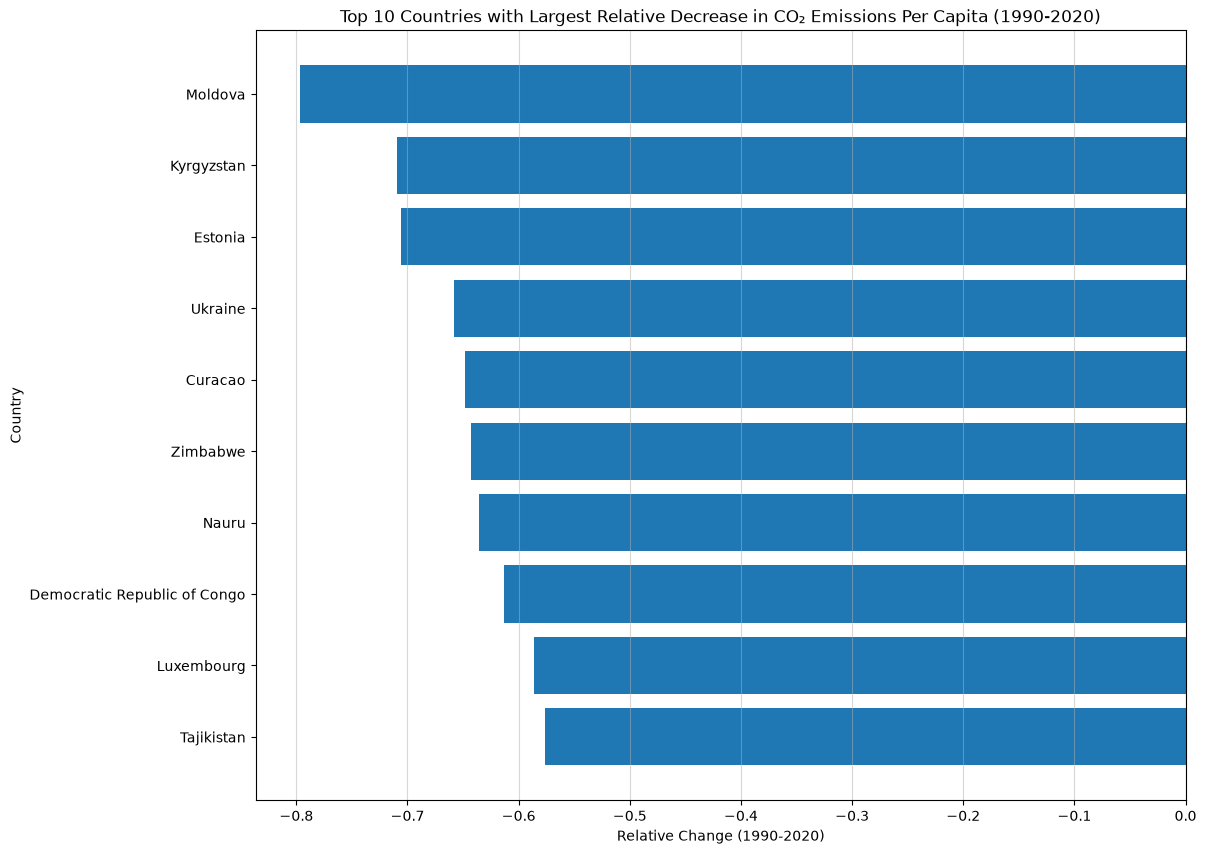

In [187]:
# Create a figure and axis object
fig, ax = plt.subplots(figsize=(12, 10))

# Create a horizontal bar chart
ax.barh(co2_top_10_1990_2020['Entity'], co2_top_10_1990_2020['relative_change_1990_2020'])
ax.invert_yaxis()

# Set title, labels, legend, grid
ax.set_title('Top 10 Countries with Largest Relative Decrease in CO₂ Emissions Per Capita (1990-2020)')
ax.set_xlabel('Relative Change (1990-2020)')
ax.set_ylabel('Country')
ax.grid(axis='x', alpha=0.5)

plt.show()

**Which countries are making the biggest strides in decreasing CO2 output?**

Based on the relative change in CO₂ emissions between 1990 and 2020, the ten countries with the largest decreases are:
1. Moldova (-0.796865)
2. Kyrgyzstan (-0.709088)
3. Estonia (-0.705663)
4. Ukraine (-0.658496)
5. Curacao (-0.647818)
6. Zimbabwe (-0.643204)
7. Nauru (-0.635221)
8. Democratic Republic of Congo (-0.612814)
9. Luxembourg (-0.586398)
10. Tajikistan (-0.575981)

The largest relative reductions occurred mainly in former Soviet states. However, these reductions should not automatically be interpreted as successful climate policy, as the economic and industrial decline following the collapse of the Soviet Union contributed substantially to falling emissions.

Sources

- [Nature: *Soviet Union’s collapse led to massive drop in carbon emissions*](https://www.nature.com/articles/d41586-019-02024-6)
- [The Daily Economy: *The Collapse of the USSR Was One the Best Things that Happened to the Environment*](https://thedailyeconomy.org/article/the-collapse-of-the-ussr-was-one-the-best-things-that-happened-to-the-environment/)


### Bonus 2000 - 2020 (Without graph)

In [166]:
df_co2_2000_2020 = df_co2_filtered.copy()

# Pivot the DataFrame to have the years as columns
df_co2_2000_2020 = df_co2_2000_2020.pivot(
  index=["Entity"],
  columns="Year",
  values="CO₂ emissions per capita"
)

df_co2_2000_2020.columns.name = None
df_co2_2000_2020.reset_index(inplace=True)
df_co2_2000_2020 = df_co2_2000_2020[['Entity', 2000, 2020]]

# Calculate relative change for 2000-2020
df_co2_2000_2020["relative_change_2000_2020"] = (df_co2_2000_2020[2020] - df_co2_2000_2020[2000]) / df_co2_2000_2020[2000]

df_co2_2000_2020.head()

,Entity,2000,2020,relative_change_2000_2020
0,Afghanistan,0.052017,0.284590,4.471045
1,Africa,1.119205,0.993473,-0.112340
2,Albania,0.955397,1.693982,0.773067
3,Algeria,2.735981,3.885795,0.420257
4,Andorra,7.974552,4.876055,-0.388548


In [167]:
df_co2_2000_2020_top_10 = df_co2_2000_2020.sort_values(by="relative_change_2000_2020", ascending=True).head(10)
df_co2_2000_2020_top_10

,Entity,2000,2020,relative_change_2000_2020
10,Aruba,26.787004,7.641079,-0.714747
52,Curacao,34.110470,10.851662,-0.681867
228,Yemen,0.806749,0.297691,-0.630999
124,Macao,3.493785,1.512655,-0.567044
202,Syria,3.277267,1.536593,-0.531136
230,Zimbabwe,1.161661,0.546847,-0.529254
56,Denmark,10.170421,4.852874,-0.522844
224,Venezuela,5.826397,2.844218,-0.511839
130,Malta,6.171891,3.089255,-0.499464
5,Angola,0.987665,0.494732,-0.499089


**Which countries are making the biggest strides in decreasing CO₂ output? (Continuation)**

The countries with the largest relative reductions in CO₂ emissions should not necessarily be considered the most successful in terms of climate policy. Political conflict and economic recession can also cause emissions to decline. For example, research on Syria (5th on the list above) found that CO₂ emissions fell substantially during the early stages of the war, with economic decline playing an important role.

Other countries, such as Denmark (7th on the list above), are known to have actively worked on reducing their CO₂ emissions.

Therefore, a reduction in CO₂ emissions alone does not explain why emissions have decreased. The figures only show the change in emissions, not the underlying causes. A more thorough investigation would be required to determine these causes, which is outside the scope of this report.

Sources

- [Statics Denmark: *Emissions of greenhouse gases*](https://www.dst.dk/en/Statistik/temaer/klima)
- [Wang et al.: *Prolonged war reverses carbon emissions from an early decline to a late increase: Evidence from Syria*](https://europepmc.org/article/MED/37690250)